# Week 5 - Expectation Maximization and Principal Component Analysis

Learning contents:

1. Mixture of Gaussians: Expectation-Maximization
    - Display results
    - Nearest Centroid-based classification
2. Principal Component Analysis
    - Generate data
    - Apply PCA
    - Display projection

## Dependencies

In [279]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import multivariate_normal, norm
from sklearn import datasets
from IPython.display import HTML

import seaborn as sns; sns.set(); sns.set_palette('bright')

## Generate Data

#### We use `iris` dataset from `sklearn` library

(<matplotlib.collections.PathCollection at 0x117a9af60>,
 <matplotlib.legend.Legend at 0x117b67500>)

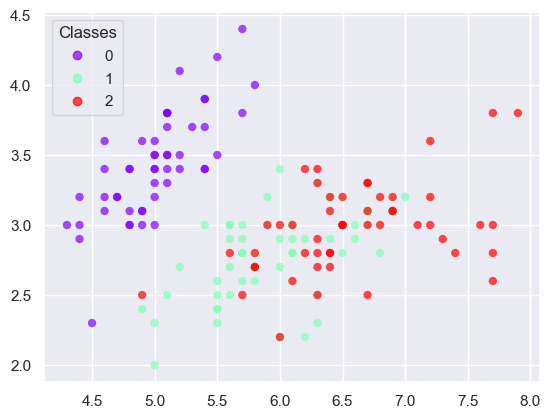

In [105]:
iris = datasets.load_iris()
iris_x = np.array(iris.data[:, :2])  # we only take the first two features.
iris_t = np.array(iris.target)

def plot_iris(legend=True, classes=iris_t, target=plt):
    scatter = target.scatter(iris_x[:, 0], iris_x[:, 1], c=classes, alpha=0.7, cmap='rainbow', edgecolor='none')
    if legend:
        legend = target.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
        return (scatter, legend)
    return (scatter, )

plot_iris()

## 1) Mixture of Gaussians: Expectation-Maximization

write a function `gaussian_mixture` that takes data point `x` (say, a vector in D-dimensional space), set of multivariate `means` and respective `covariances`, and `pis` (mixing coefficients as defined in a Gaussian mixture model) and should return PDF value of mixture model at the point x.

Formel: 
$$p(x) = \sum_{k=1}^K{\pi_k \mathscr{N}(x\lvert \mu_k, \Sigma_k)}$$

In [106]:
def gaussian_mixture(x, means, covariances, pis):
    # x in R^1xD 
    # u in R^KxD
    # ∑ in R^KxDxD
    # pi in R^K
    
    px = np.sum([
        pis[k] * multivariate_normal.pdf(x, means[k], covariances[k])    for k in range(means.shape[0])
        ])
    return px

write a function `expectation_maximization_gaussian` that takes initial mean vectors `mus_0`, initial covariance matrices `covariances_0`, initial mixing coefficient values `pis_0`, input data set `data_x` and a callback `on_step`. See Slide 14 of Lecture 9.

The `on_step` is a function that takes current set of `mus`, corresponding `covariances` and `pis`, value of `log_likelihood` and list of class `predictions` for each point and is used to record or track the parameters and outcomes of the EM algorithm at each step by storing them in the all_steps_em list. It should be called each iteration step. Remember that you do not need to define this function as it has already been defined in the later part of the code (see the function call expectation_maximization_gaussian()), you just need to call it after updating parameters in each iteration.

Evaluering: 
$$ \gamma(z_{nk}) = \frac{
    \pi_k \mathscr{N}(x_n\lvert \mu_k, \Sigma_k)
}{
    \sum_{j=1}^K{\pi_j \mathscr{N}(x_n\lvert \mu_j, \Sigma_j)}
}$$
Updatering: 

$$N_k = \sum_{n=1}^N{\gamma(z_{nk})}$$
$$\mu_k^{new} = \frac{1}{N_k}\sum_{n=1}^N {\gamma(z_{nk})x_n}$$
$$\Sigma_k^{new} = \frac{1}{N_k}\sum_{n=1}^N {\gamma(z_{nk})(x_n - \mu_k^{new})(x_n - \mu_k^{new})^T}$$
$$\pi_k^{new} = \frac{N_k}{N}$$
Evaluer log likelihood 
$$ lnp(X\lvert \mu, \Sigma, \pi) = \sum_{n=1}^N {ln{\sum_{k=1}^K{\pi_k \mathscr{N}(x_n\lvert \mu_k, \Sigma_k)} }} $$

Tjek så for konvergering af parametre eller for log likelihood. Hvis kriteriet ikke er mødt, start så forfra

In [ ]:
def expectation_maximization_gaussian(mus_0, covariances_0, pis_0, data_x, on_step):
    # data_x in R^{NxD}
    # u in R^KxD
    # ∑ in R^KxDxD
    # pi in R^K
    N = data_x.shape[0]
    K, D = mus_0.shape
    
    ikkeKonvergeret = True
    threshold = 1e-6
    globalLogLikeliHood = [100]        # Bruges til at tjekke konvergens.
    
    
    while ikkeKonvergeret : 
        
        # Evaluering
        # gamma_nk in R^{N_K}
        gamma = np.array([
            [pis_0[k] * multivariate_normal.pdf(data_x[n], mus_0[k], covariances_0[k])    for k in range(K)]
            for n in range(N)
                        ])        
        # Normalisering: /= R^{N_1}
        gamma /= np.sum(gamma, axis = 1)[:, np.newaxis]
        
        
        # Opdatering
        N_k = np.sum(gamma, axis = 0) # Sum ned ad rækkerne in R^K, 
                                                                                                                                    # gamma_n in R^1xK x_n in R^1xD. gamma_n^T * x_n in R^KxD # R^1xK * sum_n(R^NxKxD) -> R^1xK * R^KxD # Hvad med en diagonal invers? # Min lineær algebra siger, at det medføre en invers af hvert element og beholder dem på diagonalen.  A = np.array([1, 2, 5, 10]); B = np.diag(A); C = np.linalg.inv(B) # print(A);print(B); print(C) # Det gør den! # R^KxK * R^KxD # at N_k = 0 for n ≠ k skulle medføre, at til kun den klasse, som inversen tilhøre, skulle den blive normaliseret.
        mu_new = (1/N_k)[:, np.newaxis] * (gamma.T @ data_x) # R^Kx1 * R^{KxN . NxD} = R^Kx1 * R^KxD -> R^KxD
        # kovariancen skulle vidst ikke være hurtigere på vektor form
        Sigma_new = np.zeros((K, D, D))
        for k in range(K): 
            diff = data_x - mu_new[k]                   # R^NxD - R^1xD -> R^NxD
            weight = gamma[:, k][:, np.newaxis] * diff  # R^Nx1 * R^NxD -> R^NxD                 <- Elementwise operator på hver række. 
            Sigma_new[k] = 1/N_k[k] * (weight.T @ diff) # R^1x1 . R^DxN . R^NxD -> R^DxD
            
        pik_new = N_k/N 
        
        
        # Ny evaluering
        loglikelihood = np.sum(
            np.log([gaussian_mixture(x, mu_new, Sigma_new, pik_new) for x in data_x])
        )
        # Predictions? 
        # gamma fortæller om sandsynligheden for et datapunkt x i hvilken som helst klasse, normaliseret med sandsynligheden for at den bare er i en. 
        # Dermed så må den klasse hvis sandsynlighed er størst for datapunktet x betyde, at det er den klasse som den tilhøre. 
        # gamma in R^NxK 
        t = np.argmax(gamma, 1)
        
        
        # Feedback
        # On_step = lambda mus, covs, pis, log_likelihood, predictions: all_steps_em.append((mus, covs, pis, log_likelihood, predictions))
        on_step(mu_new, Sigma_new, pik_new, loglikelihood, t)
        
        # sum(loglikelihood_n) in [150*ln(0); 150*ln(1)] = [-∞; 0]
        dLikeliHood = np.abs(loglikelihood) - np.abs(globalLogLikeliHood[-1])
        if np.abs(dLikeliHood) < threshold: break 
        globalLogLikeliHood.append(np.abs(loglikelihood))
        
        
        # Nye værdier bliver til gamle
        mus_0 = mu_new
        covariances_0 = Sigma_new
        pis_0 = pik_new


### 1.1) Display results

In [161]:
def plot_gaussian_mixtures(mus, covariances, pis, data, classes, cmap='rainbow', target=plt):
    
    lx = min(data[:, 0])
    rx = max(data[:, 0])
    by = min(data[:, 1])
    uy = max(data[:, 1])

    x, y = np.mgrid[lx:rx:.01, by:uy:.01]
    pos = np.dstack((x, y))
    
    probabilities = list(map(
        lambda x: gaussian_mixture(x, mus, covariances, pis),
        pos
    ))
    probs_flat = np.array([gaussian_mixture(p, mus, covariances, pis) for p in pos.reshape(-1, 2)])
    probabilities = probs_flat.reshape(x.shape)


    target.contour(x, y, probabilities, cmap=cmap)
    
    plot = plot_iris(classes=classes, target=target)
    # scatter = target.scatter(mus[:, 0], mus[:, 1], c=[0, 1, 2], cmap='rainbow', marker='data', s=300, edgecolors='black')
    return (*plot, )


def plot_mesh(pred_fn, n_class=3, x_min=4, x_max=8, y_min=2, y_max=4.5, target=plt):
    h = 0.1  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = np.array(list(map(lambda x: pred_fn(np.array(x)), np.c_[xx.ravel(), yy.ravel()])))
    Z = Z.reshape(xx.shape)
    cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))
    target.axis('tight')
    if hasattr(target, 'xlim'):
        target.xlim(x_min, x_max)
        target.ylim(y_min, y_max)

Here, we define our initial means `mus_0`, covariance matrices `covariances_0`, mixing coefficient values `pis_0` and call the `expectation_maximization_gaussian function`. 

Note the 'lambda' function in the last function call. It is an anonymous function that takes several inputs,  captures the intermediate results of the Expectation Maximization (EM) algorithm and append them to the list all_steps_em.

In [153]:
np.random.seed(26)

classes = 3

all_steps_em = []

mus_0 = iris_x[:classes]
covariances_0 = np.array([np.cov(iris_x.T)] * classes)
pis_0 = np.array([1/classes] * classes)

expectation_maximization_gaussian(
    mus_0, covariances_0, pis_0, iris_x,
    lambda mus, covs, pis, log_likelihood, predictions: all_steps_em.append((mus, covs, pis, log_likelihood, predictions))
)
print(len(all_steps_em))


(150,)
-269.31618765450366
(150,)
-268.68351674101297
(150,)
-268.0105102932028
(150,)
-267.01840496548357
(150,)
-265.4906824017522
(150,)
-263.1703480902529
(150,)
-259.9139290677603
(150,)
-256.30027287202176
(150,)
-253.49481819601561
(150,)
-251.43160855664183
(150,)
-249.3899009222781
(150,)
-246.78392593262373
(150,)
-243.0446331097437
(150,)
-237.64980588319168
(150,)
-231.0648136460636
(150,)
-226.41556547378326
(150,)
-224.62030991093644
(150,)
-223.6530393266828
(150,)
-222.88009976283752
(150,)
-222.2266820702357
(150,)
-221.73561882340326
(150,)
-221.412398255145
(150,)
-221.20053955516943
(150,)
-221.04604776218673
(150,)
-220.91599506864864
(150,)
-220.79054431910023
(150,)
-220.6543891778672
(150,)
-220.4911266182615
(150,)
-220.27913450022606
(150,)
-219.9885468282857
(150,)
-219.5834522480319
(150,)
-219.04323891823623
(150,)
-218.41688574188325
(150,)
-217.85095068003804
(150,)
-217.47162772075393
(150,)
-217.27269478635935
(150,)
-217.18400445494888
(150,)
-217.1484

(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (361, 241) 361
(361, 241) (

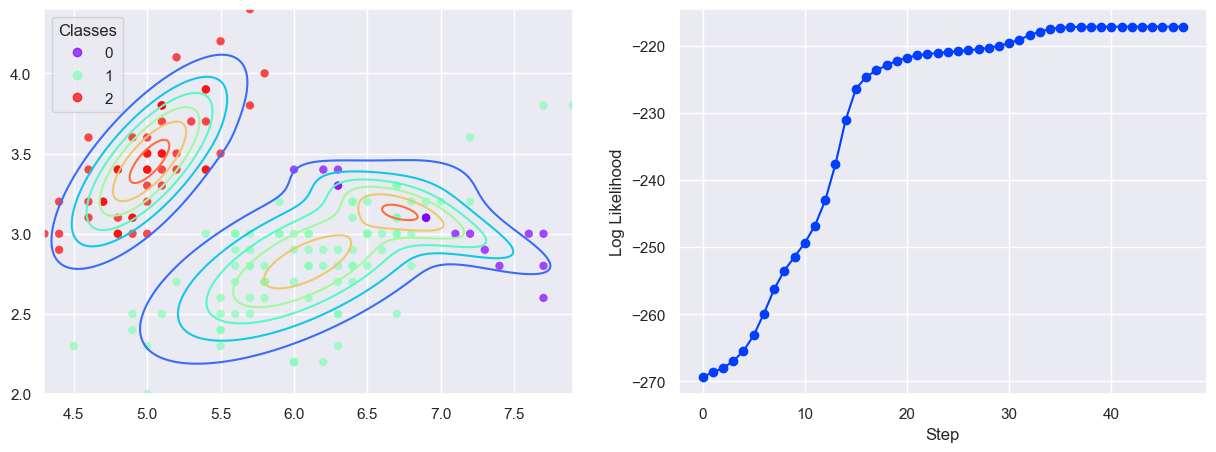

In [154]:
def create_animation(all_steps_em, data_x):
    
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15,5))
    
    log_likelihoods = list(map(lambda x: x[3], all_steps_em))
    
    def animate(i):
        ax.cla()
        ax2.cla()
        
        predictions = all_steps_em[i][4]
        
        plot1 = plot_gaussian_mixtures(all_steps_em[i][0], all_steps_em[i][1], all_steps_em[i][2], iris_x, predictions, target=ax)
                
        ax2.plot(list(range(i)), log_likelihoods[:i], '-o')
        plt.xlabel('Step')
        plt.ylabel('Log Likelihood')
        return plot1
    
    anim = FuncAnimation(
        fig, animate,
        frames=len(all_steps_em), interval=500, blit=True
    )
    return HTML(anim.to_html5_video())

create_animation(all_steps_em, iris_x)

### 1.2) Nearest Centroid-based classification

Write the `nearest_centroid_based_class` that takes (a possibly D-dimensional) data point `x`, a set of (a possibly D-dimensional) means `mus` and (a set of DxD dimensional) `covariances` and returns the predicted class of this data point based on nearest centroid based classification. See slide 17-23 of lecture 9.

Det her adskiller sig egentlig bare fra EMs evaluerings fase ved, at jeg ikke behøves at normalisere det til procent. 
$$argmax[\gamma(z_{nk}) \sum_{j=1}^K{\pi_j \mathscr{N}(x\lvert\mu,\Sigma)} = \pi_k \mathscr{N}(x\lvert\mu,\Sigma)]$$
Chatten siger at der kan være numerisk ustabilitet ved den måde at gøre det på, så den anbefaler derfor
$$argmax[ln(\mathscr{N}(x\lvert\mu,\Sigma)) + ln(\pi_k)]$$
Men nu må jeg først se om det overhovedet bliver et problem

In [ ]:
def nearest_centroid_based_class(x, mus, covariances):
    # x in R^1xD
    # u in R^KxD
    # ∑ in R^KxDxD
    K, D = mus.shape
    gamma = np.array([pis_0[k] * multivariate_normal.pdf(x, mus[k], covariances[k])    for k in range(K)])
    t = np.argmax(gamma, axis = 0)
    print(K, D, gamma.shape, t)
    return t

3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 0 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3

/var/folders/s1/8pjch1gd44lcppl6nnk77kdh0000gn/T/ipykernel_21431/915629146.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 0 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3

/var/folders/s1/8pjch1gd44lcppl6nnk77kdh0000gn/T/ipykernel_21431/915629146.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 0 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3,) 1 ()
3 2 (3

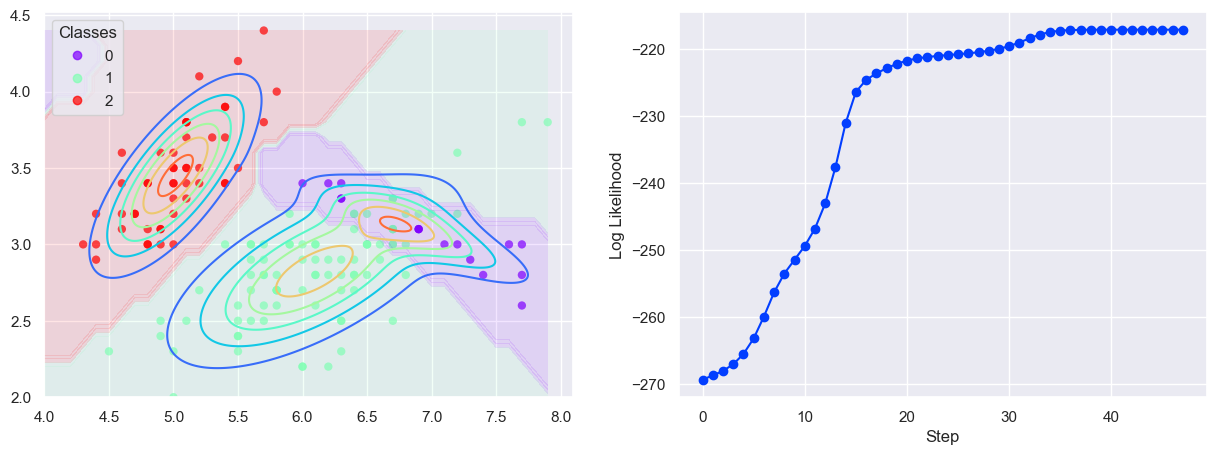

In [175]:
def create_animation(all_steps_em, data_x):
    
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15,5))
    
    log_likelihoods = list(map(lambda x: x[3], all_steps_em))
    
    def animate(i):
        ax.cla()
        ax2.cla()
        
        predictions = all_steps_em[i][4]
        
        plot1 = plot_gaussian_mixtures(all_steps_em[i][0], all_steps_em[i][1], all_steps_em[i][2], iris_x, predictions, target=ax)
        
        plot_mesh(
            lambda x: nearest_centroid_based_class(x, all_steps_em[i][0], all_steps_em[i][1]),
            n_class=len(all_steps_em[i][0]), target=ax
        )
        
        ax2.plot(list(range(i)), log_likelihoods[:i], '-o')
        plt.xlabel('Step')
        plt.ylabel('Log Likelihood')
        return plot1
    
    anim = FuncAnimation(
        fig, animate,
        frames=len(all_steps_em), interval=500, blit=True
    )
    return HTML(anim.to_html5_video())

create_animation(all_steps_em, iris_x)

## 2) Principal Component Analysis

### 2.1) Generate data

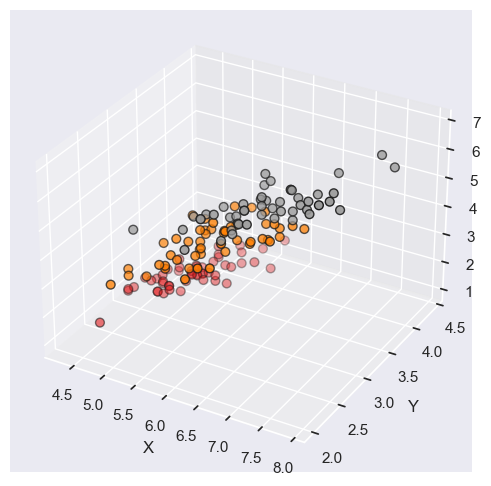

In [196]:
iris4_x = np.array(iris.data[:, :4])

from mpl_toolkits.mplot3d import Axes3D
def plot_classes_3d(data, classes):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')  # correct way to make 3D axes
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=classes,
               cmap=plt.cm.Set1, edgecolor='k', s=40)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()
plot_classes_3d(iris4_x[:, :3], iris_t)

### 2.3) Apply PCA

write a function `pca_projection` that takes input data points `data`, desired number of `components` as arguments and returns the PCA projection of the `data`. See the lecture slides 10.

Målet: 
$$\tilde{x}_{n}=\bar{x}+\sum_{i=1}^{M}(x_{n}^{T}{u}_{i}- \bar{x^T} u_i)u_i$$
For det så skal jeg få 
$$\bar{x} = \frac{\sum_N{x_n}}{N}$$
Og U vektoren bliver lavet ud fra M komponenter af egenvektorerne for covariance matricen S
$$ S = \frac{1}{N} \sum_{n=1}^N{(x_n -\bar{x})(x_n -\bar{x})^T} \Rightarrow U \in\R^{DxM} \le \R^{DxD} $$


In [274]:
# Udledning for at prøve at finde en matrix repræsentation 
# x_n . u_i                             # R^{1xD} . R^{Dx1} -> R^{1x1}
# (x_n . u_i) * u_i                     # R^{1x1} * R^{Dx1} -> R^{Dx1}
# Så hvad holder mig fra ikke bare at bruge hele datasættet? 
# X . u_i                               # R^{NxD} . R^{Dx1} -> R^{Nx1}
# (X . u_i) * u_i                       # R^{Nx1} * R^{Dx1} <- Ugyldig
# (X . u_i) * u_i.T                     # R^{Nx1} . R^{1xD} -> R^{NxD} 

# Men jeg har jo hellere ikke U? 
# X . U                                 # R^{NxD} . R^{DxM} -> R^{NxM}
# (X . U) * U                           # R^{NxM} * R^{DxM} <- Ugyldig
# (X . U) * U.T                         # R^{NxM} * R^{MxD} -> R^{NxD}

# How jeg mangler forskellen 
# x_mean . U                            # R^{1xD} . R^{DxM} -> R^{1xM}
# X . U  -  x_mean . U                  # R^{NxM} . R^{1xM} <- Ugyldig
# X . U  -  (x_mean . U)^T              # R^{NxM} . R^{Mx1} -> R^{Nx1}

# Så den strategi virker faktisk ikke.
# Kan jeg redistribuere? 
# x_n^T u_i - x_bar^Tu_i                # R^{Dx1} . R^{1xD} - R^{Dx1} . R^{1xD} -> R^{DxD} - R^{DxD}
# (x_n - x_bar)^T u_i                   # R^{Dx1} . R^{1xD} -> R^{DxD}

# (X - X_mean) @ U.T                    # R^{NxD} . R^{DxM} -> R^{NxM}
# xtilde = X_mean + (X - X_mean) @ U.T  # R^{NxD} . R^{DxM} 

# Jeg kunne ikke finde det selv, så jeg fandt formlen online. 

def pca_projection(data, components):
    N, D = data.shape
    M = components
    # Steps: 
    #   1. Find x_mean 
    #   2. Lav covariance matrix 
    #   3. Find tilsvarende egenvektorer.
    #   4. Lav x pca approximation. 
    
    X = data
    # X in R^{NxD} 
    # X_mean in R^{1xD}
    X_mean = 1/N * np.sum(data, axis=0)[:, np.newaxis].T
    diff = X - X_mean           # <- Elementvis operation på rækkeren   R^{NxD} - R^{1xD} -> R^{NxD}
    
    # S = 1/N * (diff @ diff.T)             # R^{1x1} * (R^{NxD} . R^{DxN) -> R^{NxN}   <- Ugyldig
    S = 1/N * (diff.T @ diff)               # R^{1x1} * (R^{DxN} . R^{NxD) -> R^{DxD}
    eigVals, eigVecs = np.linalg.eig(S)     # R^{D, }, R^{DxD}
    
    # Egenværdierne er sorteret efter største værdi først allerede. 
    U = eigVecs[:, :M]                      # R^{DxM}                 
    
    # Jeg prøvede at udlede en repræsentation selv, men jeg fandt ikke et rigtig resultat 
    
    # Af en eller anden grund er min U flippet i forhold til Naveeds, så for at få det samme som ham så ukommenter det her. 
    # U *= -1 
    # Chatten fortæller at retningen er ligegyldigt, at det bare er ud fra den måde egenværdierne er beregnet. 
    # Så hvis han ikke lige har brugt præcis np.linalg.eig kan det være at de har andre konventioner.
    
    
    xtilde = X @ U
    return xtilde

### 2.4) Display projection

(<matplotlib.collections.PathCollection at 0x11a8a97f0>,
 <matplotlib.legend.Legend at 0x11a816900>)

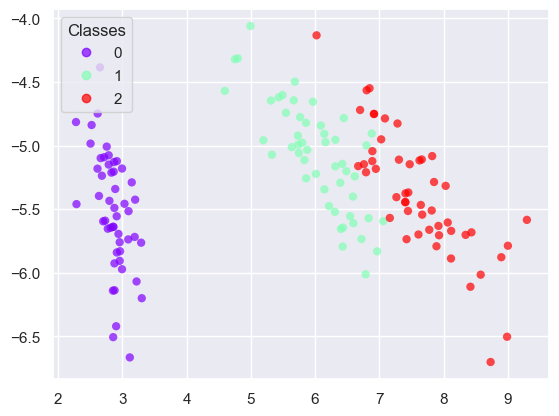

In [275]:
def plot_classes(data, classes, legend=True, target=plt):
    scatter = target.scatter(data[:, 0], data[:, 1], c=classes, alpha=0.7, cmap='rainbow', edgecolor='none')
    if legend:
        legend = target.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
        return (scatter, legend)
    return (scatter, )

projected_data = pca_projection(iris4_x, 2)
plot_classes(projected_data, iris_t)

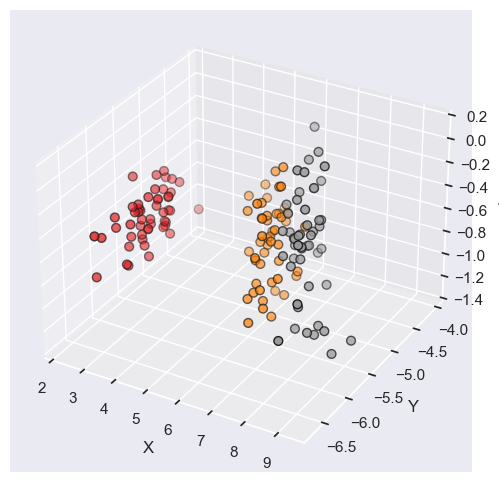

In [276]:
projected_data = pca_projection(iris4_x, 3)
plot_classes_3d(projected_data, iris_t)